In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pytesseract import image_to_string
import os
from ultralytics import YOLO
import pandas as pd

os.environ['TESSDATA_PREFIX'] = os.environ['TESSDATA_PREFIX'] = './tessdata'

# YOLO model for box detection 

In [10]:
# Load trained YOLO model
yolov8obb = YOLO("./yolov8-obb/blood_pressure_monitors.v2i.yolov8-obb/runs/obb/train3/weights/last.pt")  # pretrained YOLOv8n model


# ✅ select obb with highest confidence 
def select_obb(obbs):
    cls = obbs.cls.tolist()
    conf = obbs.conf.tolist()
    highest_conf_obb = {}
    for idx, (cls_idx, conf_value) in enumerate(zip(cls, conf)):
        cls_idx = int(cls_idx)
        if cls_idx not in highest_conf_obb or conf_value > highest_conf_obb[cls_idx][1]:
            highest_conf_obb[cls_idx] = (idx, conf_value)
    return highest_conf_obb

# ✅ Model detect sys/dia/pul obb
def yolov8obb_pred(img_path, model):
    results = model(
        img_path,
        verbose = False
    )
    result = results[0]
    obbs = result.obb
    highest_conf_obb = select_obb(obbs)

    return {
        "ssd": obbs[highest_conf_obb[2][0]] if 2 in highest_conf_obb else None,
        "sys": obbs[highest_conf_obb[3][0]] if 3 in highest_conf_obb else None,
        "dia": obbs[highest_conf_obb[0][0]] if 0 in highest_conf_obb else None,
        "pul": obbs[highest_conf_obb[1][0]] if 1 in highest_conf_obb else None,
    }

In [11]:
def select_obb(obbs):
    cls = obbs.cls.tolist()
    conf = obbs.conf.tolist()
    
    highest_conf_obb = {}
    
    for idx, (cls_idx, conf_value) in enumerate(zip(cls, conf)):
        cls_idx = int(cls_idx)
        if cls_idx not in highest_conf_obb:
            highest_conf_obb[cls_idx] = (idx, conf_value)
        else:
            if conf_value > highest_conf_obb[cls_idx][1]:
                highest_conf_obb[cla_idx] = (idx, conf_value)
                
    return highest_conf_obb

def yolov8obb_pred(img_path, model):
    # results = model(img_path)
    results = model(img_path, 
                    verbose=False)
    
    result = results[0]
    obbs = result.obb
    highest_conf_obb = select_obb(obbs)
    ssd = highest_conf_obb[2]
    sys = highest_conf_obb[3]
    dia = highest_conf_obb[0]
    pul = highest_conf_obb[1]
    return obbs[ssd[0]], obbs[sys[0]], obbs[dia[0]], obbs[pul[0]]


In [12]:
def extract_and_binarize_obb(image_path, obb, obb_cls):
    # 1. 读取图像（BGR + uint8）
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    # 2. 提取 OBB 顶点坐标
    xyxyxyxy = obb.xyxyxyxy[0].cpu().numpy()       # (8,)
    points = xyxyxyxy.reshape(-1, 2).astype(np.int32)  # (4, 2)

    # 3. 创建 mask 并填充 OBB 区域
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [points], 255)

    # 4. 生成 masked_image（背景清零）
    masked_image = cv2.bitwise_and(image, image, mask=mask)

    # 5. 裁剪 ROI 区域
    expand = 5  # 向四周扩张的像素数，可调（比如 5~10）

    x, y, w, h = cv2.boundingRect(points)
    x = max(x - expand, 0)
    y = max(y - expand, 0)
    w = min(w + 2*expand, image.shape[1] - x)
    h = min(h + 2*expand, image.shape[0] - y)
    roi_color = masked_image[y:y+h, x:x+w]   # 彩色 ROI
    roi_mask = mask[y:y+h, x:x+w]            # ROI 区域对应 mask

    # 6. 灰度化 + 掩膜外清零
    roi_gray = cv2.cvtColor(roi_color, cv2.COLOR_BGR2GRAY)
    roi_gray[roi_mask == 0] = 0

    # 8. 保存三张图片   
    save_dir1 = os.path.join('roi_color', obb_cls)
    save_dir2 = os.path.join('roi_gray', obb_cls)
    os.makedirs(save_dir1, exist_ok=True)
    os.makedirs(save_dir2, exist_ok=True)
    cv2.imwrite(os.path.join(save_dir1, image_path), roi_color)
    cv2.imwrite(os.path.join(save_dir2, image_path), roi_gray)

    # 10. 可视化
    fig, ax = plt.subplots(2, 2, figsize=(10, 10))
    ax[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax[0, 0].set_title("Original Image"); ax[0, 0].axis('off')

    ax[0, 1].imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
    ax[0, 1].set_title("Masked Image"); ax[0, 1].axis('off')

    ax[1, 0].imshow(roi_gray, cmap='gray')
    ax[1, 0].set_title("Gray ROI"); ax[1, 0].axis('off')

    ax[1, 1].imshow(roi_gray, cmap='gray')
    ax[1, 1].set_title("Binary ROI"); ax[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    return roi_color, roi_gray

# Preprocess image for OCR 

In [13]:
def preprocess_img(img):
    img_binary = img.copy()
    img_binary[img_binary >= 10] = 255
    img_binary[img_binary < 10] = 0

    contours, _ = cv2.findContours(img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, epsilon, True)

    if len(approx) != 4:
        print("⚠️ 没找到四边形，试着调大/调小 epsilon")
    else:
        pts = approx.reshape(4, 2)

        # 4. 对点排序（左上、右上、右下、左下）
        rect = np.zeros((4, 2), dtype="float32")
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]   # 左上
        rect[2] = pts[np.argmax(s)]   # 右下
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)] # 右上
        rect[3] = pts[np.argmax(diff)] # 左下

        # 5. 计算目标矩形尺寸
        widthA = np.linalg.norm(rect[2] - rect[3])
        widthB = np.linalg.norm(rect[1] - rect[0])
        maxWidth = int(max(widthA, widthB))

        heightA = np.linalg.norm(rect[1] - rect[2])
        heightB = np.linalg.norm(rect[0] - rect[3])
        maxHeight = int(max(heightA, heightB))

        # 6. 构造变换矩阵 & 透视变换
        dst = np.array([
            [0, 0],
            [maxWidth - 1, 0],
            [maxWidth - 1, maxHeight - 1],
            [0, maxHeight - 1]
        ], dtype="float32")

        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))

        # 7. 显示结果
        plt.subplot(1,2,1)
        plt.title("Original")
        plt.imshow(img, cmap='gray')

        plt.subplot(1,2,2)
        plt.title("Corrected")
        plt.imshow(warped, cmap='gray')
        plt.show()

        warped = warped[3:-3, 3:-3]
        _, preprocessed_img = cv2.threshold(
            warped, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        plt.imshow(preprocessed_img, cmap="gray")
        plt.axis('off')

    return preprocessed_img

def img_to_string(img):
    return image_to_string(img,  config=("-l ssd --psm 7")).strip()
        

# Method 1: pytesseract

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


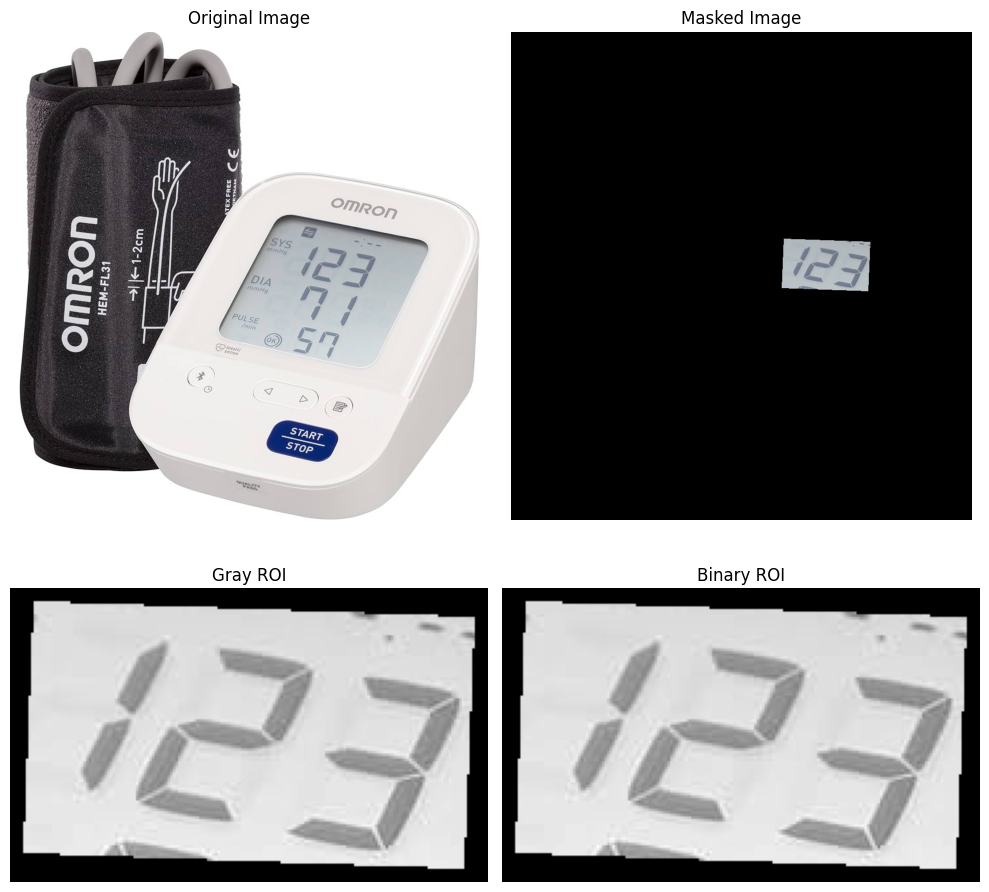

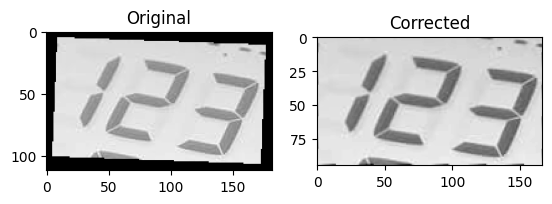

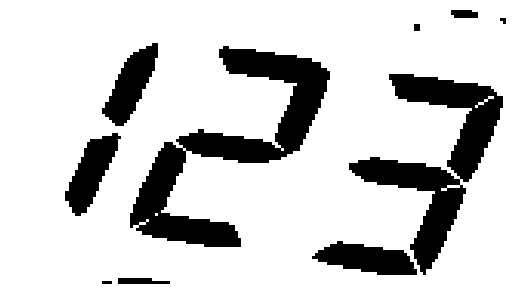

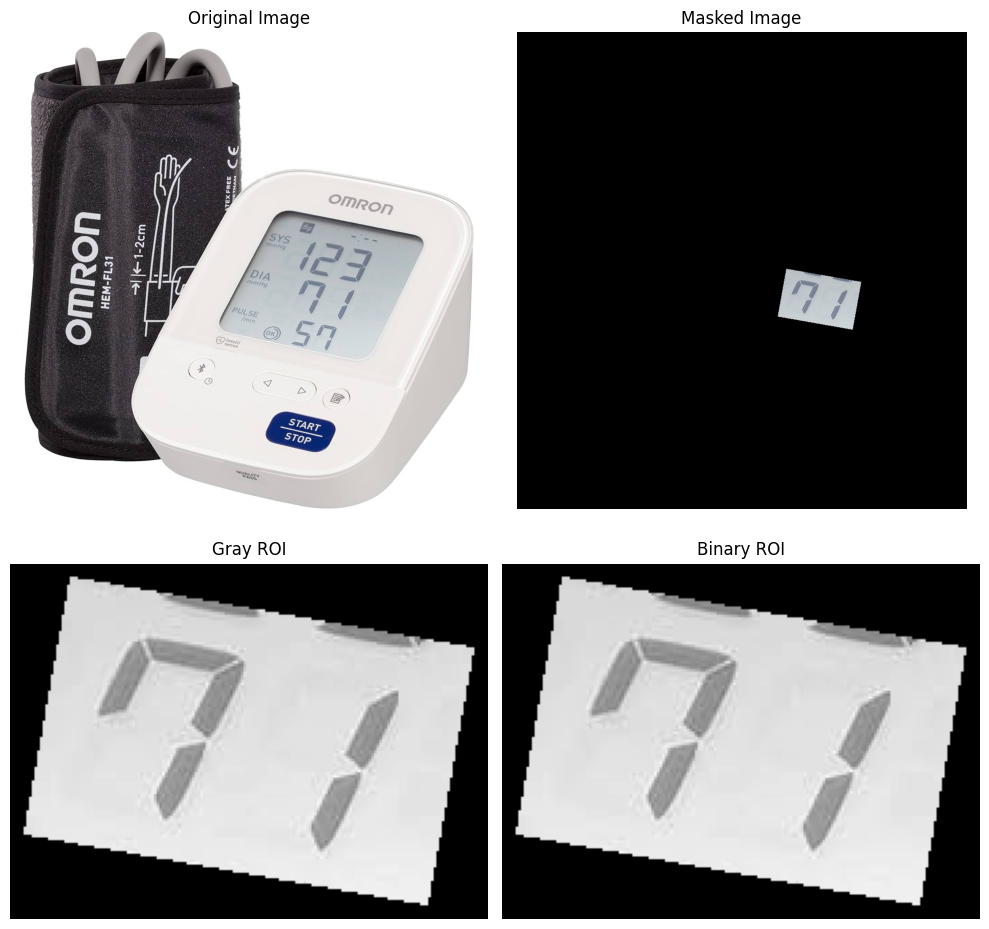

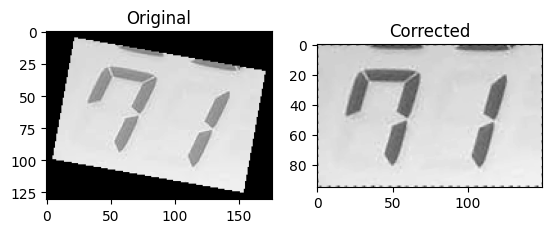

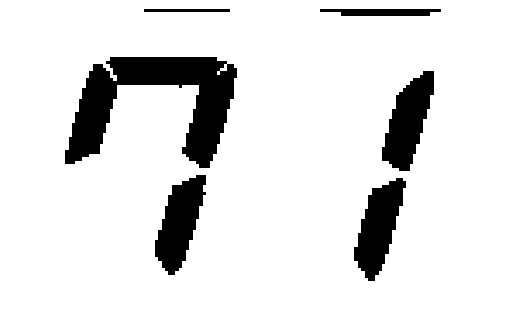

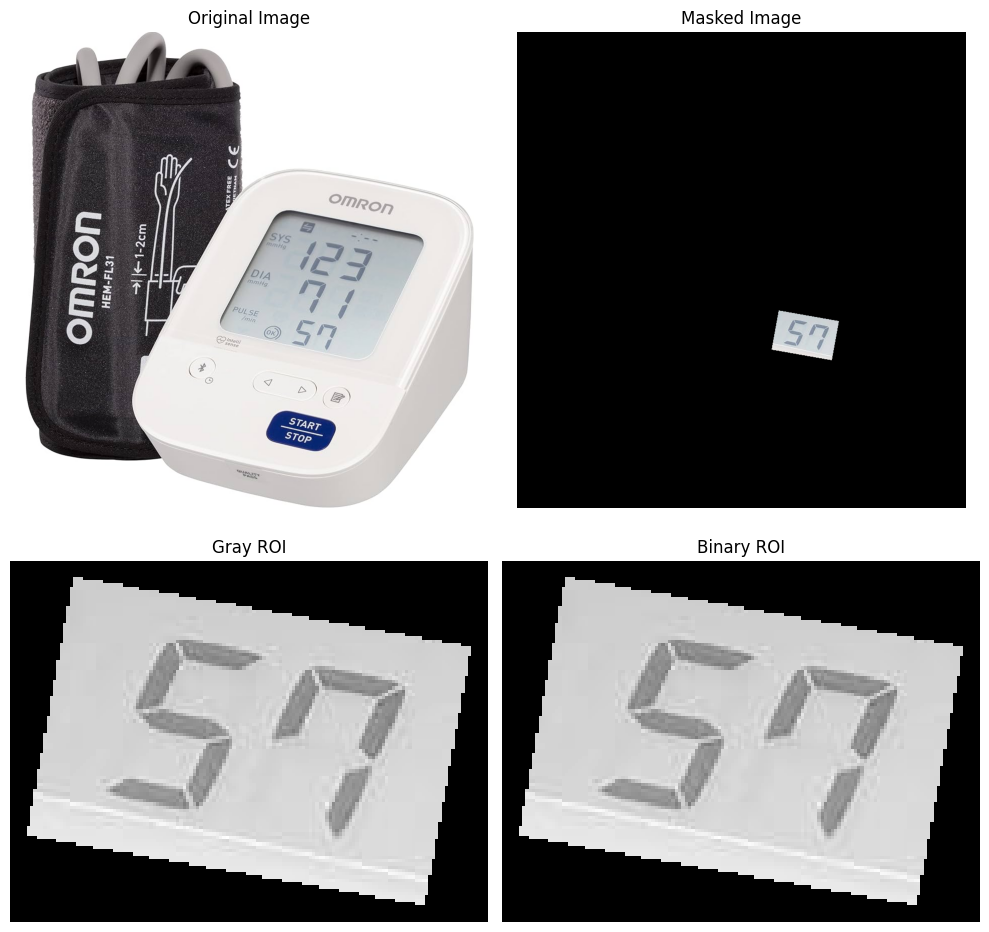

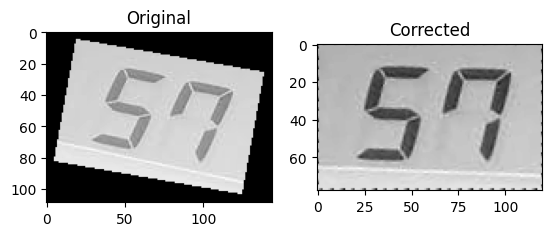

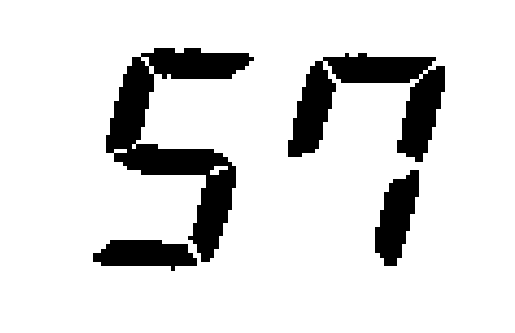

In [14]:
def bp_ocr(img_path, model_box):
    ssd, sys, dia, pul = yolov8obb_pred(img_path, model_box)
    if sys:
        roi_color_sys, roi_gray_sys = extract_and_binarize_obb(img_path, sys, 'sys')
        sys_val = img_to_string(preprocess_img(roi_gray_sys))
    else:
        sys_val = 0
    if dia:
        roi_color_dia, roi_gray_dia = extract_and_binarize_obb(img_path, dia, 'dia')
        dia_val = img_to_string(preprocess_img(roi_gray_dia))
    else:
        dia_val = 0
    if pul:
        roi_color_pul, roi_gray_pul = extract_and_binarize_obb(img_path, pul, 'pul')
        pul_val = img_to_string(preprocess_img(roi_gray_pul))
    else:
        pul_val = 0
    
    return sys_val, dia_val, pul_val

sys_val, dia_val, pul_val = bp_ocr("5.jpg", yolov8obb)
    

In [15]:
print(sys_val, dia_val, pul_val)
print(int(sys_val), int(dia_val), int(pul_val))

/23 71 57


ValueError: invalid literal for int() with base 10: '/23'

# YOLO-Based-Digit-Detection-for-LED-Displays

In [16]:
# Load trained YOLO model
digit_yolov8 = YOLO("gh_yolov8_best.pt")  # pretrained YOLOv8n model

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ✅ select obb with highest confidence 
def select_obb(obbs):
    cls = obbs.cls.tolist()
    conf = obbs.conf.tolist()
    highest_conf_obb = {}
    for idx, (cls_idx, conf_value) in enumerate(zip(cls, conf)):
        cls_idx = int(cls_idx)
        if cls_idx not in highest_conf_obb or conf_value > highest_conf_obb[cls_idx][1]:
            highest_conf_obb[cls_idx] = (idx, conf_value)
    return highest_conf_obb

# ✅ Model detect sys/dia/pul obb
def yolov8obb_pred(img_path, model):
    results = model(
        img_path,
        verbose = False
    )
    result = results[0]
    obbs = result.obb
    highest_conf_obb = select_obb(obbs)

    return {
        "ssd": obbs[highest_conf_obb[2][0]] if 2 in highest_conf_obb else None,
        "sys": obbs[highest_conf_obb[3][0]] if 3 in highest_conf_obb else None,
        "dia": obbs[highest_conf_obb[0][0]] if 0 in highest_conf_obb else None,
        "pul": obbs[highest_conf_obb[1][0]] if 1 in highest_conf_obb else None,
    }

# ✅ Model 2：Detect 7-segment digits（return boxes and names）
def yolov8digit_pred(img_path, model):
    results = model(
        img_path,
        verbose = False
    )
    boxes = results[0].boxes
    names = results[0].names
    return boxes, names

# ✅ Whether center point of 7-segment digit box in the sys/dia/plu detected box
def point_in_box(point, box):
    x1, y1, x2, y2 = box.xyxy.cpu().numpy().flatten()
    return x1 <= point[0] <= x2 and y1 <= point[1] <= y2

# ✅ extract_digits_for_box
def extract_digits_for_box(digits_boxes, indicator_box, names, conf_thresh=0.3):
    digit_list = []
    for i, box in enumerate(digits_boxes.xyxy):
        if digits_boxes.conf[i] < conf_thresh:
            continue
        x1, y1, x2, y2 = box.tolist()
        center = ((x1 + x2) / 2, (y1 + y2) / 2)
        if point_in_box(center, indicator_box):
            cls_idx = int(digits_boxes.cls[i])
            digit_value = names[cls_idx][-1]  # e.g. 'D7' -> '7'
            digit_list.append((center[0], digit_value))
    digit_list.sort(key=lambda d: d[0])
    return "".join([d[1] for d in digit_list]) if digit_list else "N/A"

def visualize_results(img_path, obbs_dict, digit_boxes, names):
    # Read the original image and convert to RGB
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Create a 1x2 subplot layout for side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    ax1, ax2 = axes

    # ---------- 📍 Left: Model 1 (sys/dia/pul detection) ----------
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title("Model 1: Blood Pressure Region Detection", fontsize=18)

    # Define colors for each class
    colors = {"sys": "red", "dia": "blue", "pul": "green", "ssd": "orange"}
    for key, obb in obbs_dict.items():
        # ✅ Skip if this class was not detected
        if obb is None:
            print(f"⚠️ No {key.upper()} box detected, skipping drawing.")
            continue

        # Extract coordinates (top-left and bottom-right points)
        x1, y1, x2, y2 = obb.xyxy.cpu().numpy().flatten()

        # Define rectangle corners for plotting
        rect_points = np.array([
            [x1, y1],
            [x2, y1],
            [x2, y2],
            [x1, y2]
        ])

        # Draw the bounding box
        rect = plt.Polygon(rect_points, fill=False, edgecolor=colors[key], linewidth=2)
        ax1.add_patch(rect)

        # Add label above the box
        ax1.text(
            x1, y1 - 10,
            f"{key.upper()}",
            color=colors[key], fontsize=14, weight="bold",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)
        )

    # ---------- 📍 Right: Model 2 (digit detection) ----------
    ax2.imshow(img)
    ax2.axis('off')
    ax2.set_title("Model 2: 7-Segment Digit Detection", fontsize=18)

    # Draw each digit detection result
    for i, box in enumerate(digit_boxes.xyxy):
        x1, y1, x2, y2 = box.tolist()
        cls_idx = int(digit_boxes.cls[i])
        label = names[cls_idx][-1]  # 'D7' -> '7'
        conf = float(digit_boxes.conf[i])

        # Draw rectangle for digit box
        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1, y2 - y1,
            fill=False, edgecolor="yellow", linewidth=1.5
        )
        ax2.add_patch(rect)

        # Add digit label and confidence above the box
        ax2.text(
            x1, y1 - 5,
            f"{label} ({conf:.2f})",
            color="yellow", fontsize=12, weight="bold",
            bbox=dict(facecolor="black", alpha=0.5, edgecolor="none", pad=2)
        )

    # Adjust layout and show the figure
    plt.tight_layout()
    plt.show()

# ✅ main
def bp_detect(img_path, visualize):
    # load models
    model_box = yolov8obb       # model 1：detect sys/dia/pul
    model_digit = digit_yolov8   # model 2: detect digits


    obbs_dict = yolov8obb_pred(img_path, model_box)

    digit_boxes, names = yolov8digit_pred(img_path, model_digit)
    sys_value = extract_digits_for_box(digit_boxes, obbs_dict["sys"], names) if obbs_dict["sys"] is not None else "N/A"
    dia_value = extract_digits_for_box(digit_boxes, obbs_dict["dia"], names) if obbs_dict["dia"] is not None else "N/A"
    pul_value = extract_digits_for_box(digit_boxes, obbs_dict["pul"], names) if obbs_dict["pul"] is not None else "N/A"


    # 4️⃣ results
    # print("✅ OCR results")
    # print(f"SYS(Systolic): {sys_value}")
    # print(f"DIA(Diastolic): {dia_value}")
    # print(f"PUL(Pulse):   {pul_value}")

    # 5️⃣ visulization
    if visualize == True:
        visualize_results(img_path, obbs_dict, digit_boxes, names)
        
    return sys_value, dia_value, pul_value



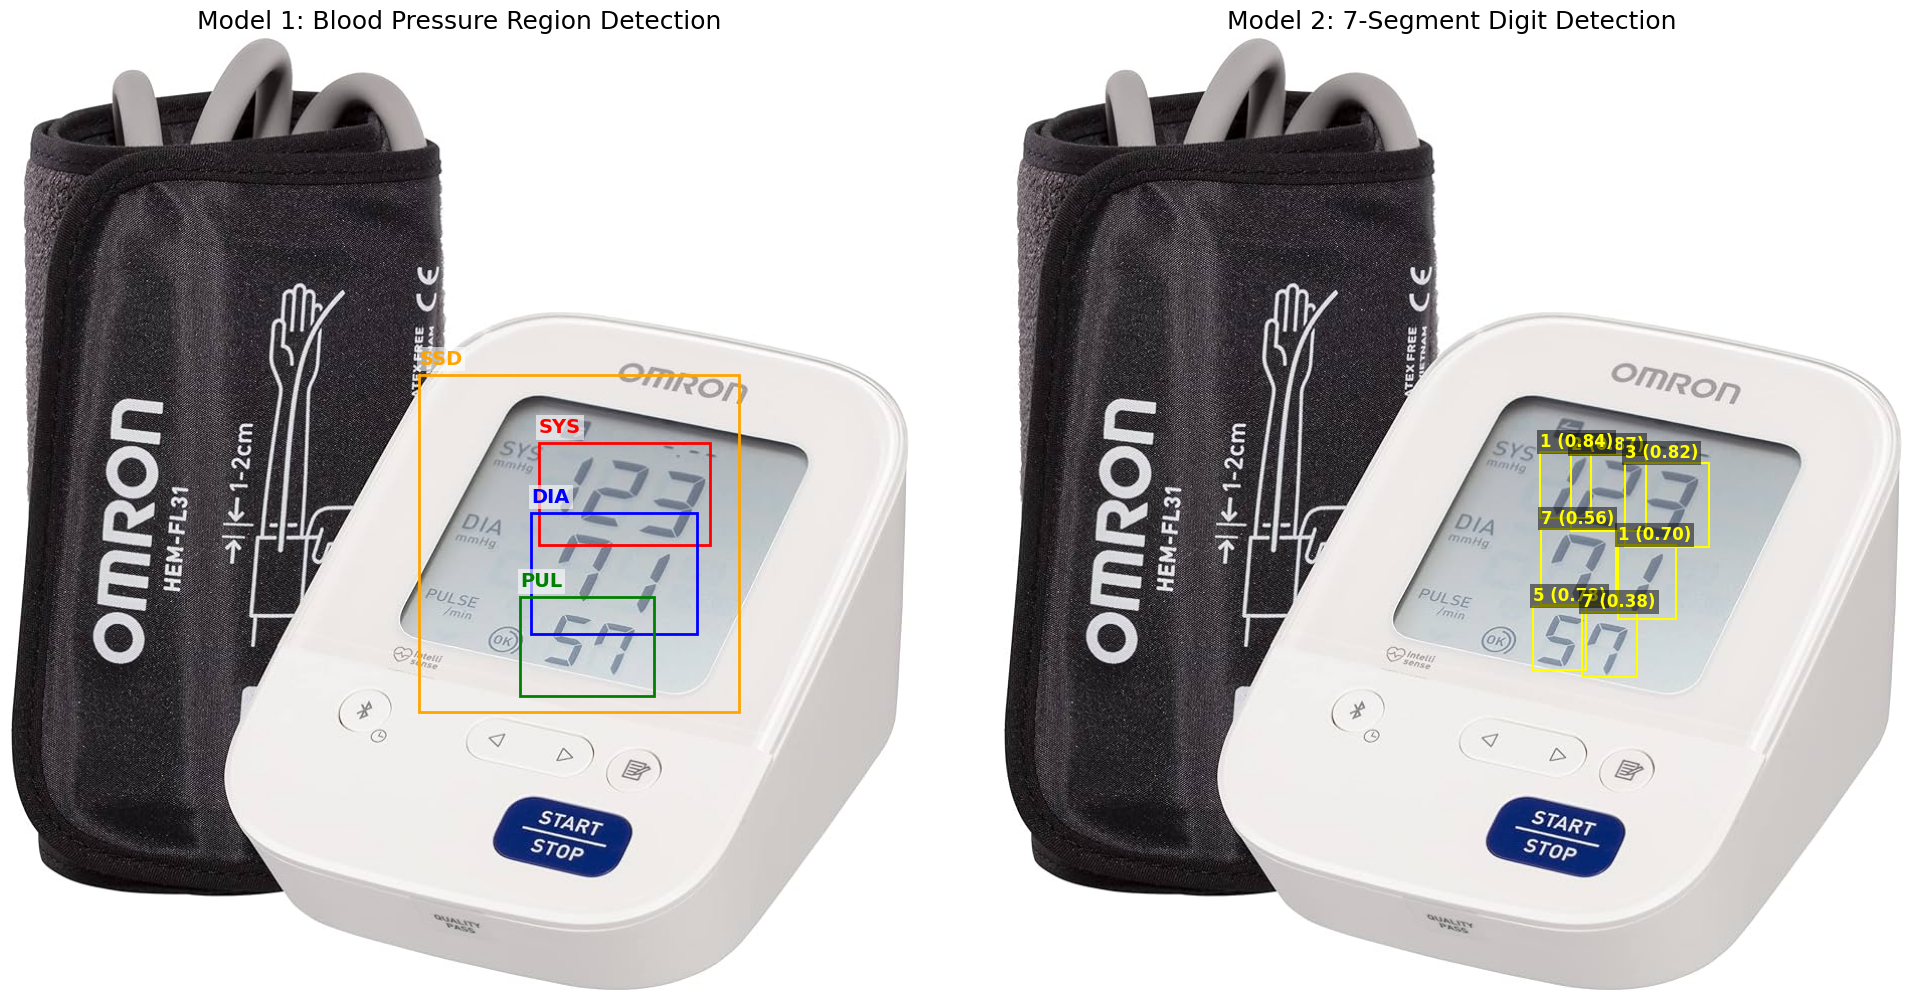

In [25]:
sys_value, dia_value, pul_value = bp_detect("5.jpg", visualize=True)